# Dự đoán khả năng sống sót của hành khách trên tàu titanic

## 1. Định nghĩa vấn đề

**Bối cảnh**

Vụ đắm tàu RMS Titanic năm 1912 là một trong những thảm họa hàng hải nổi tiếng nhất trong lịch sử.<br>
Bài toán Titanic - Machine Learning from Disaster trên Kaggle là một ví dụ kinh điển trong lĩnh vực học máy.

**Mục tiêu**
- Xây dựng mô hình học máy dự đoán xác suất sống sót của hành khách.
- So sánh hiệu suất giữa các mô hình khác nhau
- Phân tích các yếu tố ảnh hưởng đến khả năng sống sót.

**Dữ liệu vào:** Các đặc trưng nhân khẩu học và thông tin chuyến đi.
 1. PassengerId
 2. Survived
 3. Pclass
 4. Name
 5. Sex
 6. Age
 7. SibSp
 8. Parch
 9. Ticket
10. Fare
11. Cabin
12. Embarked

**Kết quả:** Survived (0: Tử vong, 1: Sống sót)

**Cách đánh giá Kaggle Score:** Accuracy

## 2. Chuẩn bị vấn đề

### Khai báo thư viện cần thiết

In [1]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

# Load libraries
import os, sys
from IPython import display
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import ticker

import pandas as pd
import seaborn as sns
import joblib
import pprint
import random

# preprocessing
sys.path.append(os.path.abspath('..')) 
from src import preprocessing, evaluation, visualization
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# composer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# algorithms
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc

import warnings

%matplotlib inline

warnings.filterwarnings("ignore")

### Khai báo các tham số

In [2]:
params_cfg = {
    'action': globals().get('action', 'main_feat01'),
    'seed': globals().get('seed', 42),
    'exps_dir': globals().get('exps_dir', '../../exps'),
    'exp_name': globals().get('exp_name', 'titanic_01_feature_engineering'),
    'data_dir': globals().get('data_dir', '../../data/titanic'),
    'verbose': globals().get('verbose', False),
    'k_folds': globals().get('k_folds', 10),
    'output_dir': globals().get('output_dir', '../outputs/01_feature_engineering'),
}

params_cfg.update(**{'save_dir': os.path.abspath(f'{params_cfg["exps_dir"]}/{params_cfg["exp_name"]}')})

for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

globals().update(**params_cfg)

+ action: main_feat01
+ seed: 42
+ exps_dir: ../../exps
+ exp_name: titanic_01_feature_engineering
+ data_dir: ../../data/titanic
+ verbose: False
+ k_folds: 10
+ output_dir: ../outputs/01_feature_engineering
+ save_dir: d:\Data\Code\Python\ML WS\exps\titanic_01_feature_engineering


### Đọc dữ liệu từ csv

In [3]:
df_train = pd.read_csv(f'{params_cfg["data_dir"]}/train.csv')
df_test = pd.read_csv(f'{params_cfg["data_dir"]}/test.csv')

if params_cfg["verbose"]:
    print("-"*10, "information", "-"*10)
    print(f'train-col: {set(df_train.columns)}')
    print(f'test-col: {set(df_test.columns)}')
    print("Union:", set(df_train.columns).intersection(set(df_test.columns)))
    print("Difference:", set(df_train.columns).difference(set(df_test.columns)))

## 3. Feature Engineering

- FamilySize
- IsAlone
- TitleGroup
- Cabin
- AgeBin
- FareBin

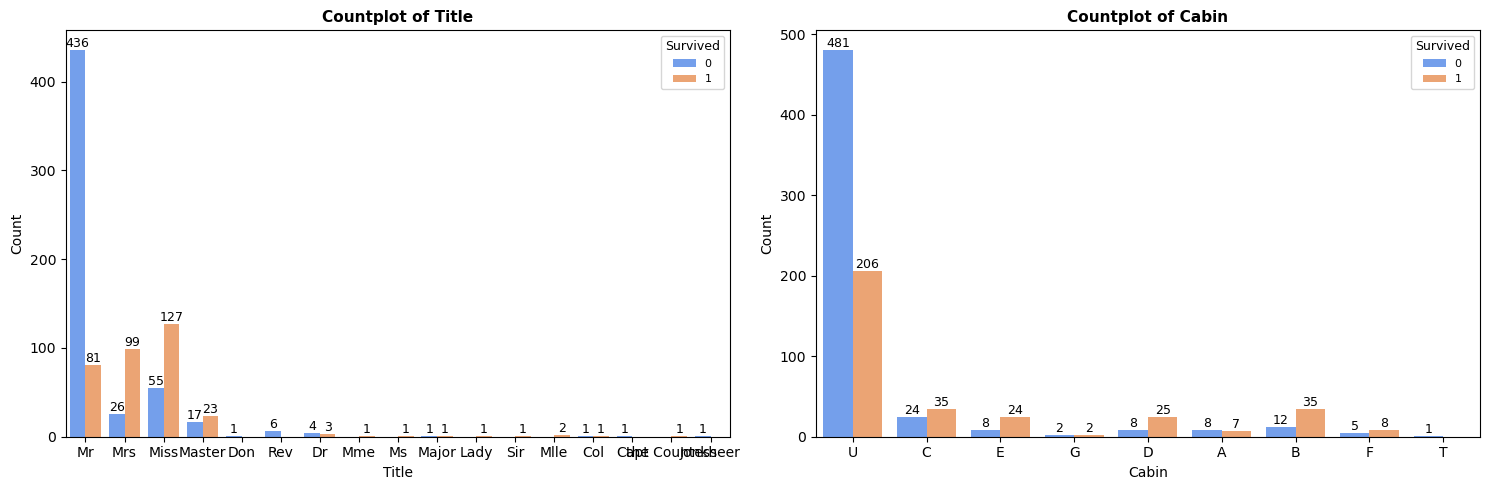

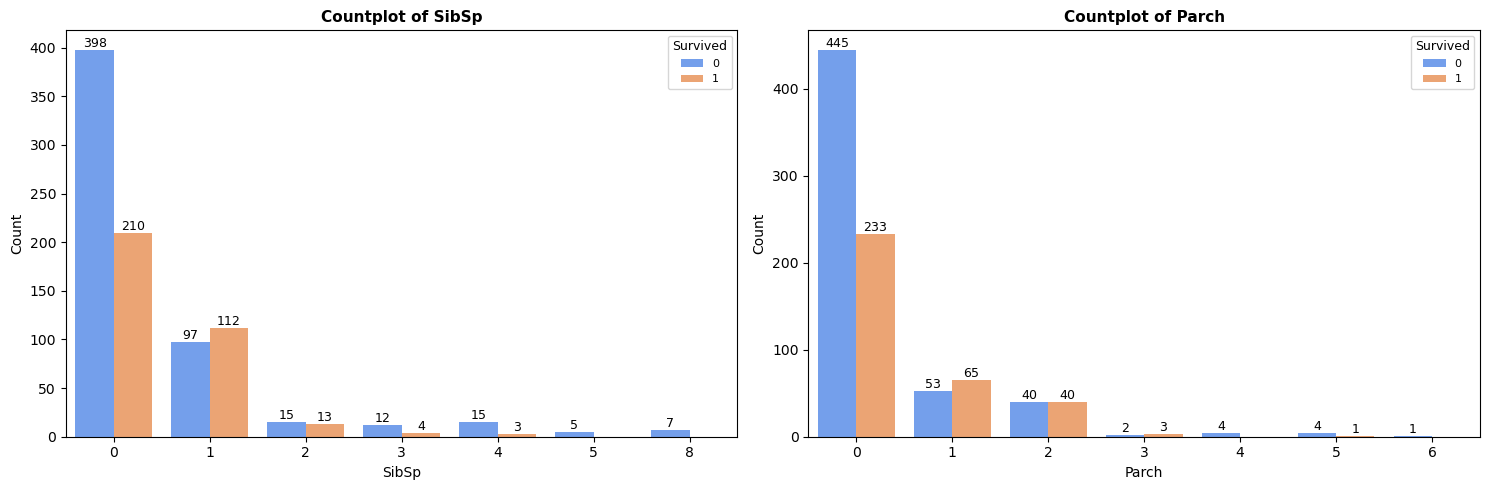

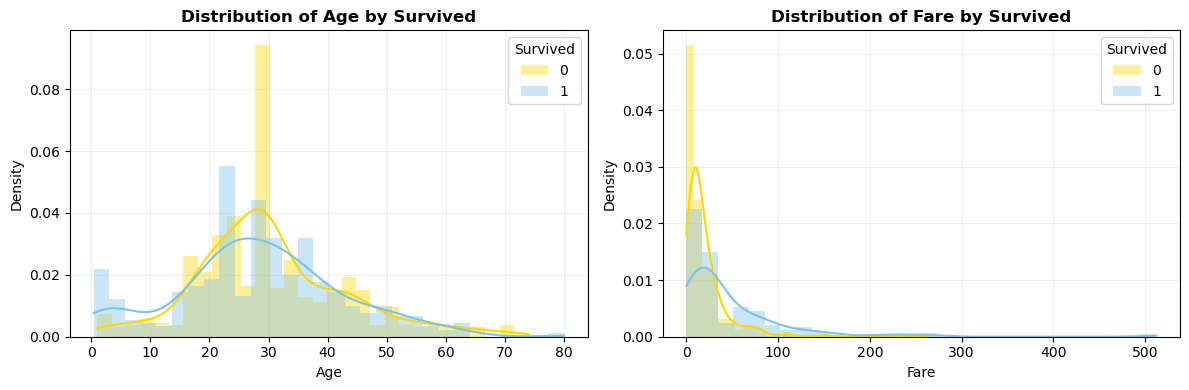

After feature engineering:


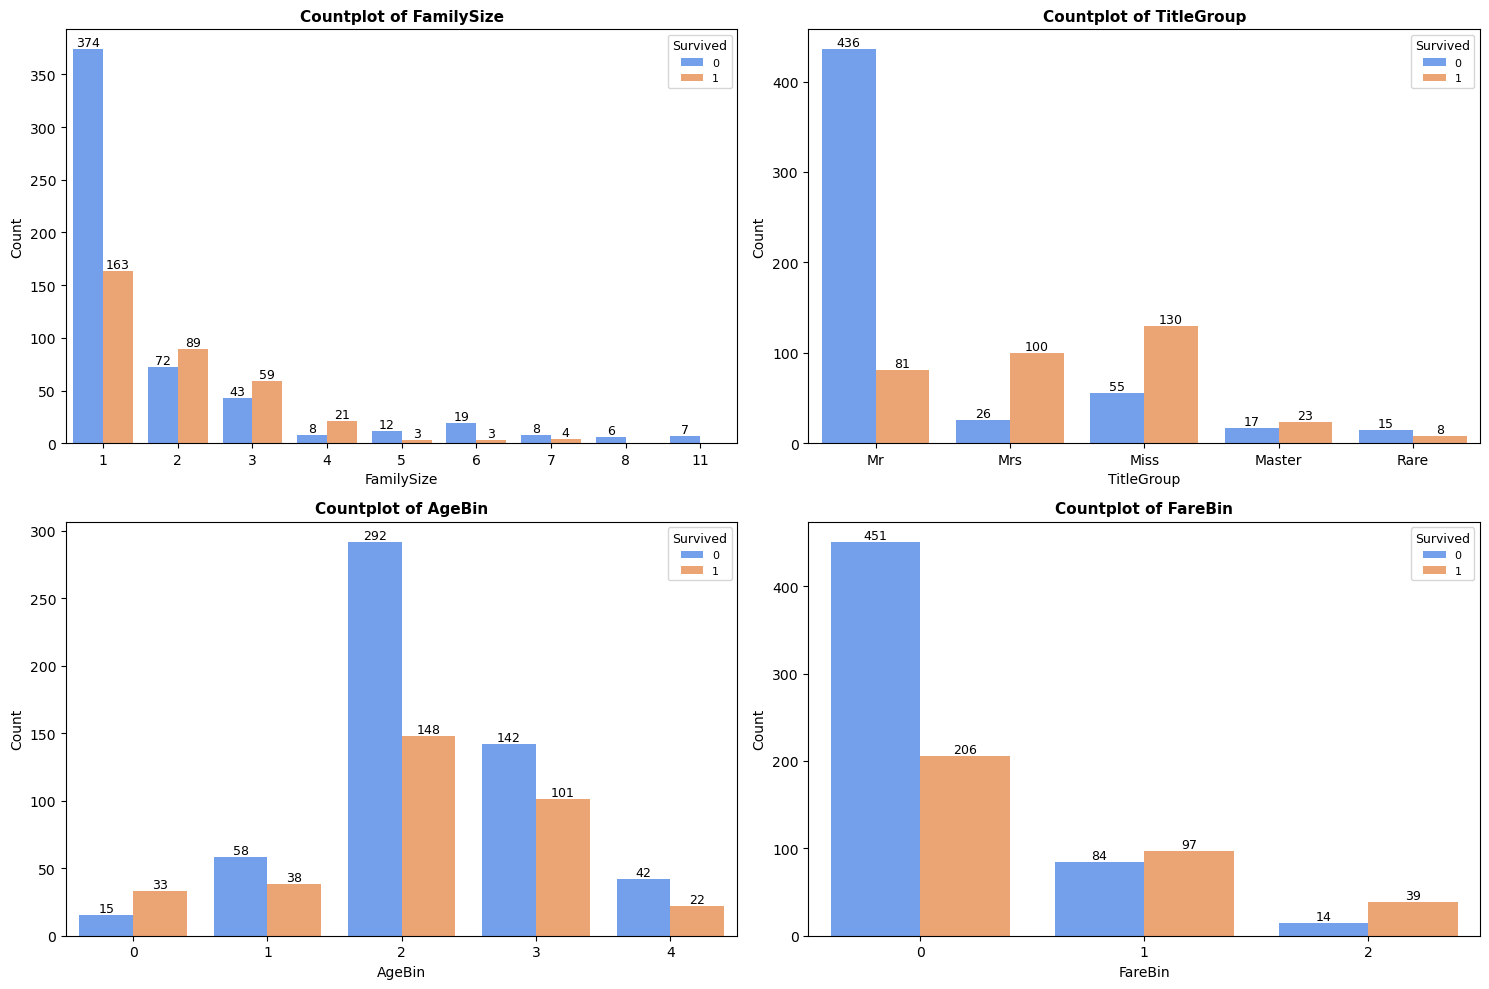

,Age,Fare,Embarked,Cabin,Pclass,SibSp,Parch,Sex,Survived,FamilySize,IsAlone,TitleGroup,AgeBin,FareBin
0,22.0,7.2500,S,U,3,1,0,male,0,2,0,Mr,2,0
1,38.0,71.2833,C,C,1,1,0,female,1,2,0,Mrs,3,1
2,26.0,7.9250,S,U,3,0,0,female,1,1,1,Miss,2,0
3,35.0,53.1000,S,C,1,1,0,female,1,2,0,Mrs,3,1
4,35.0,8.0500,S,U,3,0,0,male,0,1,1,Mr,3,0


,Age,Fare,Embarked,Cabin,Pclass,SibSp,Parch,Sex,Survived,FamilySize,IsAlone,TitleGroup,AgeBin,FareBin
0,22.000000,7.2500,S,U,3,1,0,male,0,2,0,Mr,2,0
1,38.000000,71.2833,C,C,1,1,0,female,1,2,0,Mrs,3,1
2,26.000000,7.9250,S,U,3,0,0,female,1,1,1,Miss,2,0
3,35.000000,53.1000,S,C,1,1,0,female,1,2,0,Mrs,3,1
4,35.000000,8.0500,S,U,3,0,0,male,0,1,1,Mr,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.000000,13.0000,S,U,2,0,0,male,0,1,1,Rare,2,0
887,19.000000,30.0000,S,B,1,0,0,female,1,1,1,Miss,2,0
888,27.232143,23.4500,S,U,3,1,2,female,0,4,0,Miss,2,0
889,26.000000,30.0000,C,C,1,0,0,male,1,1,1,Mr,2,0


In [4]:
def feature_engineering(df, is_train=False, is_debug=False):
    df_output = df.copy()
    # Feature engineering
    # FamilySize
    df_output['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    # IsAlone
    df_output['IsAlone'] = (df_output['FamilySize'] == 1).astype(int)
    # Title from Name
    df_output['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
    # Map rare titles to 'Rare' and standardize common titles
    title_mapping = {
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs',
        'Dr': 'Rare',
        'Rev': 'Rare',
        'Major': 'Rare',
        'Col': 'Rare',
        'the Countess': 'Rare',
        'Capt': 'Rare',
        'Sir': 'Rare',
        'Lady': 'Rare',
        'Don': 'Rare',
        'Jonkheer': 'Rare',
        'Dona': 'Rare'
    }
    df_output['TitleGroup'] = df_output['Title'].replace(title_mapping).fillna('Rare')
    # First letter of Cabin
    df_output['Cabin'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
    # Bin Age
    age_bins = [-1, 6, 18, 32, 50, 100]
    df_output['AgeBin'] = pd.cut(df_output['Age'], bins=age_bins, labels=False)
    # Bin Fare
    fare_bins = [-1, 30, 100, 600]
    df_output['FareBin'] = pd.cut(df_output['Fare'], bins=fare_bins, labels=False).astype('int')

    if is_debug:
        visualization.plot_countplots(df_output, ['Title', 'Cabin'], target='Survived' if is_train else None, n_cols=2)
        visualization.plot_countplots(df, ['SibSp', 'Parch'], target='Survived' if is_train else None, n_cols=2)
        visualization.plot_distribution(df, ['Age', 'Fare'], group_col='Survived' if is_train else None)
        print("After feature engineering:")
        visualization.plot_countplots(df_output, ['FamilySize', 'TitleGroup', 'AgeBin', 'FareBin'], target='Survived' if is_train else None, n_cols=2, figsize=(15, 10))
        display.display(df_output.drop(columns=['Name', 'Title']).head())
        
    df_output.drop(columns=['Name', 'Title'], inplace=True)
    return df_output

feature_engineering(preprocessing.preprocessing_02(df_train, is_train=True), is_train=True, is_debug=True)

In [5]:
def main_feat01(**kwargs):
    # load data
    df_train = pd.read_csv(f'{params_cfg["data_dir"]}/train.csv')
    df_test = pd.read_csv(f'{params_cfg["data_dir"]}/test.csv')
    # preprocessing
    df_output_train = preprocessing.preprocessing_02(df_train, is_train=True)
    df_output_train = feature_engineering(df_output_train, is_train=True, is_debug=params_cfg["verbose"])

    df_output_test = preprocessing.preprocessing_02(df_test, is_train=False)
    df_output_test = feature_engineering(df_output_test, is_train=False, is_debug=params_cfg["verbose"])

    # saving
    os.makedirs(params_cfg["save_dir"], exist_ok=True)

    df_output_train.to_excel(f'{params_cfg["save_dir"]}/data_train.xlsx', index=False)
    df_output_test.to_excel(f'{params_cfg["save_dir"]}/data_test.xlsx', index=False)

    kwargs.get('global_cfg', {}).update(**locals())
    pass

if params_cfg["action"] == "main_feat01":
    print("Runing ... [main_feat01]")
    main_feat01(global_cfg = globals())

Runing ... [main_feat01]


## 4. Dữ liệu kiểm nghiệm

**Chiến lược:**
+ Hold-out (tiếp tục chia 7/3 với train/valid)
+ k-fold (chia thành k phần đều nhau với k-1 phần cho train/1 phần cho valid)
+ Trong đó, train là dùng huấn luyện và valid dùng điều chỉnh tham số

**Tải data đã làm sạch**

In [6]:
df_train = pd.read_excel(f'{params_cfg["save_dir"]}/data_train.xlsx')

X_train, y_train = df_train.drop(columns='Survived'), df_train['Survived'].astype(int)

In [7]:
print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print('-'*10, 'Sample data', '-'*10)
display.display(df_train.sample(5))

X_train shape: (891, 13), y_train shape: (891,)
---------- Sample data ----------


,Age,Fare,Embarked,Cabin,Pclass,SibSp,Parch,Sex,Survived,FamilySize,IsAlone,TitleGroup,AgeBin,FareBin
156,16.0,7.7333,Q,U,3,0,0,female,1,1,1,Miss,1,0
821,27.0,8.6625,S,U,3,0,0,male,1,1,1,Mr,2,0
321,27.0,7.8958,S,U,3,0,0,male,0,1,1,Mr,2,0
133,29.0,26.0000,S,U,2,1,0,female,1,2,0,Mrs,2,0
429,32.0,8.0500,S,E,3,0,0,male,1,1,1,Mr,2,0


## 5. Preprocessing

In [8]:
# One-hot encoding for categorical features
from sklearn.impute import SimpleImputer


categorical_features = ['Embarked', 'TitleGroup']
# Scale numerical features
numerical_features = ['Age', 'Fare']
# Label encoding for ordinal features
ordinal_features = ['Sex', 'Cabin']

preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ('imp', SimpleImputer(strategy='median'), numerical_features),
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_features),
        ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features)
    ], remainder='passthrough'
)

#### Data sau khi encoding, scaling

In [9]:
df_review = preprocessor_pipeline.fit_transform(X_train)
df_review = pd.DataFrame(df_review, columns=preprocessor_pipeline.get_feature_names_out())
print(f'After encoding and scaling, data shape: {df_review.shape}')
df_review.head()

After encoding and scaling, data shape: (891, 19)


,imp__Age,imp__Fare,num__Age,num__Fare,cat__Embarked_Q,cat__Embarked_S,cat__TitleGroup_Miss,cat__TitleGroup_Mr,cat__TitleGroup_Mrs,cat__TitleGroup_Rare,ord__Sex,ord__Cabin,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__FamilySize,remainder__IsAlone,remainder__AgeBin,remainder__FareBin
0,22.0,7.2500,-0.572611,-0.502445,0.0,1.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,1.0,0.0,2.0,0.0,2.0,0.0
1,38.0,71.2833,0.628077,0.786845,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0,2.0,0.0,3.0,1.0
2,26.0,7.9250,-0.272439,-0.488854,0.0,1.0,1.0,0.0,0.0,0.0,0.0,8.0,3.0,0.0,0.0,1.0,1.0,2.0,0.0
3,35.0,53.1000,0.402948,0.420730,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,0.0,2.0,0.0,3.0,1.0
4,35.0,8.0500,0.402948,-0.486337,0.0,1.0,0.0,1.0,0.0,0.0,1.0,8.0,3.0,0.0,0.0,1.0,1.0,3.0,0.0


## 6. Lượng giá thuật toán

### 6.1 Baseline

In [10]:
kfold = KFold(n_splits=params_cfg['k_folds'], shuffle=True, random_state=params_cfg['seed'])
print(f"+ X_train: {len(X_train)}")
for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
    print(f'Fold {fold+1}: ')
    print(f'+ train_idx/valid_idx:\n {valid_idx}')
    pass

+ X_train: 891
Fold 1: 
+ train_idx/valid_idx:
 [ 23  30  39  44  63  66  67  70  72  86 110 120 136 137 141 168 174 192
 196 198 204 208 210 211 215 235 244 250 254 266 280 290 294 299 300 309
 311 312 319 333 344 350 357 360 362 396 408 422 426 439 446 447 448 477
 485 493 532 538 539 585 591 605 620 621 653 659 673 682 696 709 720 739
 767 772 778 790 793 802 819 820 822 833 835 837 840 842 853 877 886 889]
Fold 2: 
+ train_idx/valid_idx:
 [  5  10  25  31  33  49  54  65  76  77  78  82  84  96  97 109 139 165
 209 213 218 227 231 275 281 286 291 292 296 306 321 323 327 338 342 359
 363 375 388 398 416 417 433 442 457 462 465 481 494 507 512 514 518 521
 527 529 541 545 572 578 584 590 594 599 604 611 625 643 652 657 668 669
 670 688 712 736 773 777 785 796 808 814 830 845 849 852 854 876 885]
Fold 3: 
+ train_idx/valid_idx:
 [  2   7  29  55  60  79  81 101 118 133 148 155 158 199 212 239 247 259
 260 265 298 302 305 316 326 331 346 355 361 365 367 377 380 382 390 404
 405 409 412

Model [LR]:
+ params = {'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
+ acc = [0.8333333333333334, 0.797752808988764, 0.8202247191011236, 0.797752808988764, 0.8426966292134831, 0.8764044943820225, 0.797752808988764, 0.7528089887640449, 0.7640449438202247, 0.898876404494382]
+ mean_acc = 0.818165 +/- 0.043809


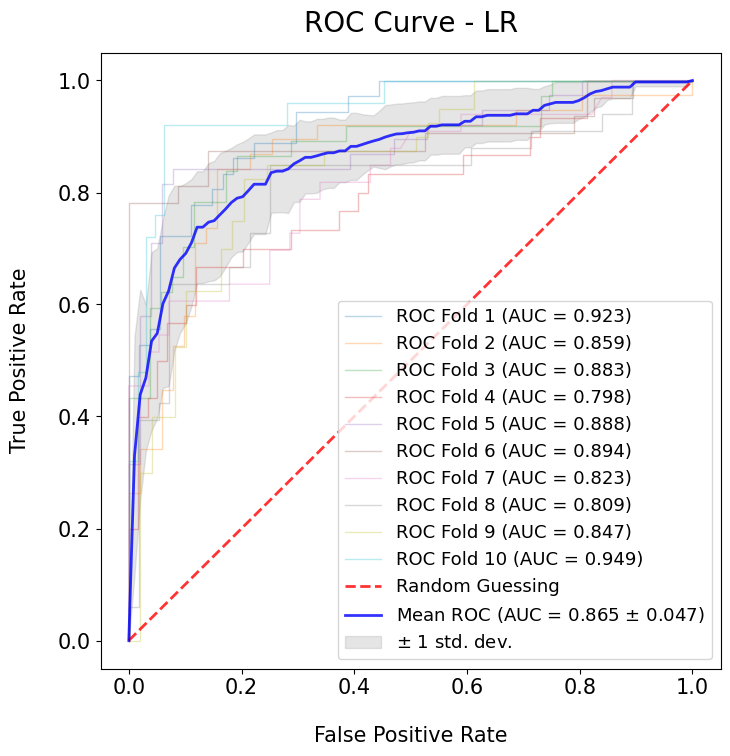


Model [LDA]:
+ params = {'covariance_estimator': None, 'n_components': None, 'priors': None, 'shrinkage': None, 'solver': 'svd', 'store_covariance': False, 'tol': 0.0001}
+ acc = [0.8444444444444444, 0.797752808988764, 0.8202247191011236, 0.797752808988764, 0.8539325842696629, 0.8876404494382022, 0.7865168539325843, 0.8089887640449438, 0.7752808988764045, 0.898876404494382]
+ mean_acc = 0.827141 +/- 0.040333


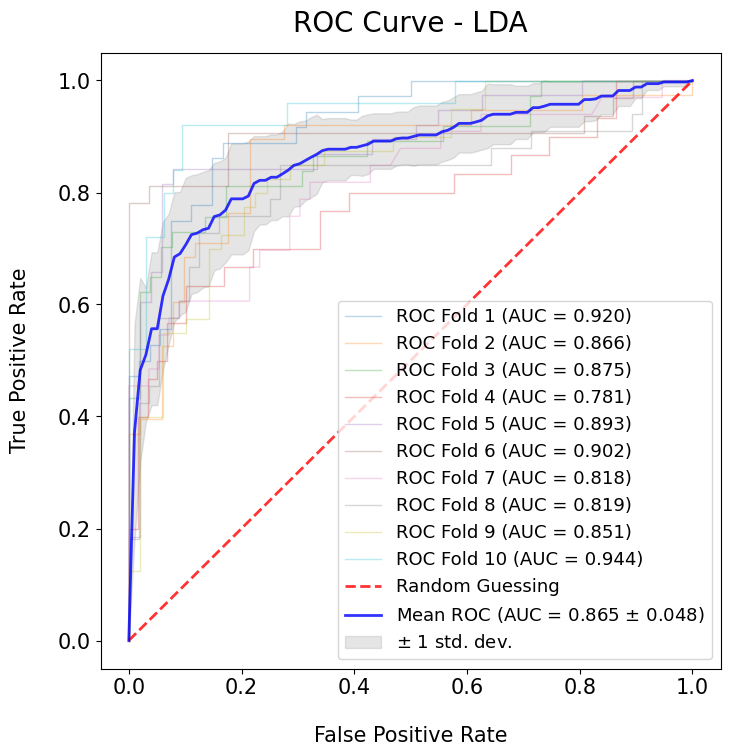


Model [KNN]:
+ params = {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
+ acc = [0.7777777777777778, 0.7752808988764045, 0.651685393258427, 0.7191011235955056, 0.7078651685393258, 0.7415730337078652, 0.7303370786516854, 0.7303370786516854, 0.6966292134831461, 0.797752808988764]
+ mean_acc = 0.732834 +/- 0.041028


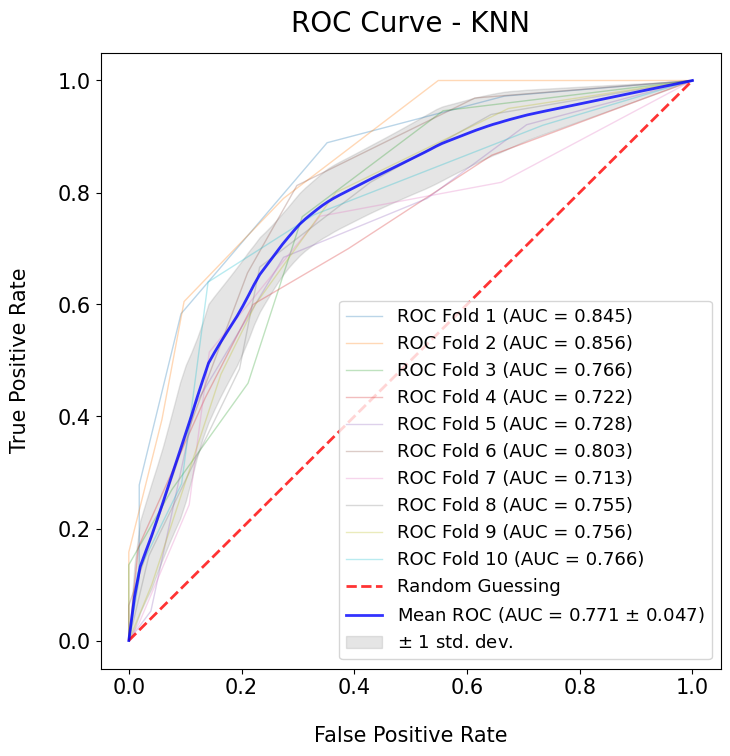


Model [RF]:
+ params = {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
+ acc = [0.8555555555555555, 0.8202247191011236, 0.797752808988764, 0.7865168539325843, 0.8426966292134831, 0.8651685393258427, 0.7415730337078652, 0.8202247191011236, 0.8089887640449438, 0.8876404494382022]
+ mean_acc = 0.822634 +/- 0.040266


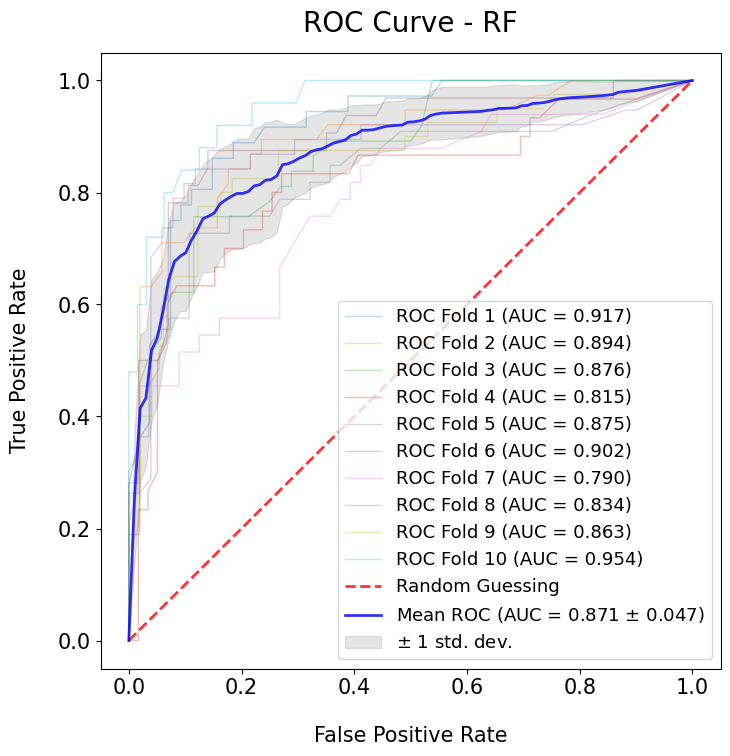


Model [SVM]:
+ params = {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
+ acc = [0.6888888888888889, 0.6629213483146067, 0.6741573033707865, 0.7528089887640449, 0.6853932584269663, 0.6853932584269663, 0.6629213483146067, 0.6629213483146067, 0.6292134831460674, 0.7752808988764045]
+ mean_acc = 0.687990 +/- 0.041674


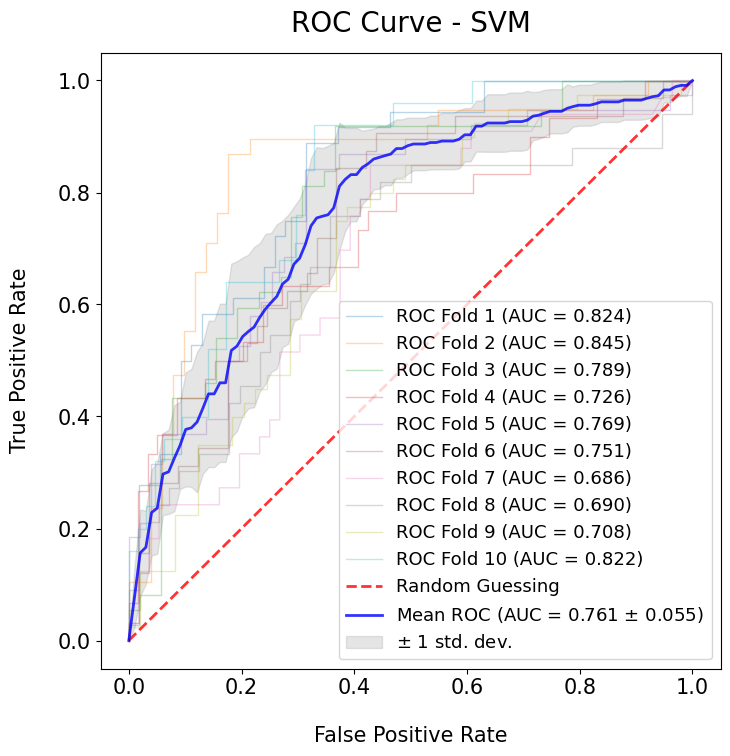

In [11]:
# Mô hình mặc định (models, results, hyper-parameters)
baseline_models  = {}
acc_results = {}
auc_results = {}

# khởi tạo các tham số mặc định
baseline_models = {
    'LR': LogisticRegression(random_state=params_cfg['seed']),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN': KNeighborsClassifier(),
    'RF': RandomForestClassifier(random_state=params_cfg['seed']),
    'SVM': SVC(random_state=params_cfg['seed'], probability=True),
}

# Huấn luyện từng mô hình cơ sở
for model_name in baseline_models:

    acc_results[model_name] = []
    auc_results[model_name] = []
    fprs = []
    tprs = []

    print(f'Model [{model_name}]:')

    # Chiến lược chia dữ liệu trên tập X_train
    kfold = KFold(n_splits=params_cfg["k_folds"], shuffle=True, random_state=params_cfg["seed"])

    for fold, (train_idx, valid_idx) in enumerate(kfold.split(X_train, y_train)):
        # Chia 2 tập thành train/valid
        X1_train, y1_train = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X1_valid, y1_valid = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

        # Lấy mô hình khởi tạo
        model_clf = sklearn.base.clone(baseline_models[model_name])
        pipe = Pipeline(steps=[('preprocessor', preprocessor_pipeline),
                               ('model', model_clf)])
        # Huấn luyện mô hình
        pipe.fit(X1_train, y1_train)

        # Lượng giá mô hình
        y1_pred_valid = pipe.predict(X1_valid)
        y1_prob_valid = pipe.predict_proba(X1_valid)[:, 1]

        # Tính toán metrics: accuracy
        valid_acc = accuracy_score(y1_valid, y1_pred_valid)
        acc_results[model_name].append(valid_acc)
        
        fpr, tpr, _ = roc_curve(y1_valid, y1_prob_valid)
        fprs.append(fpr)
        tprs.append(tpr)

        pass

    print(f'+ params = {baseline_models[model_name].get_params()}')
    print(f'+ acc = {acc_results[model_name]}')

    # trung bình kết quả +/ std cho tất cả các fold,
    # std: độ lệch chuẩn=> nếu cùng mean thì độ lệch nào nhỏ hơn thì tốt hơn vì ổn định và tập trung hơn
    s_msg = f'+ mean_acc = {np.mean(acc_results[model_name]):.6f} +/- {np.std(acc_results[model_name]):.6f}'
    print(s_msg)
    evaluation.plot_roc_curve(fprs=fprs, tprs=tprs, title=f'ROC Curve - {model_name}')
    print()

    # Huấn luyện lại với trên toàn bộ dữ liệu train (re-fit all train_data)
    pipe = Pipeline(steps=[('preprocessor', preprocessor_pipeline),
                               ('model', baseline_models[model_name])])
    pipe.fit(X_train, y_train)
    pass # model

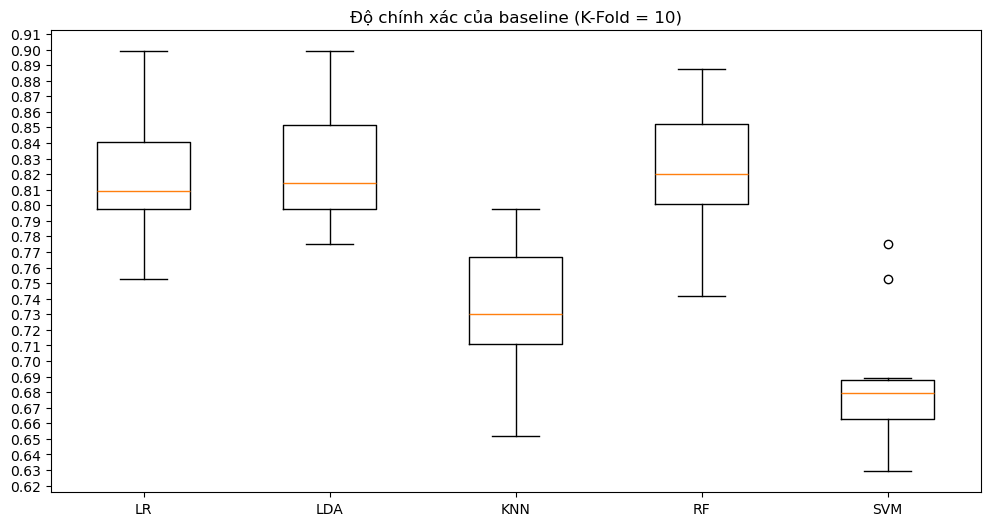

In [12]:
plt.figure(figsize=(12,6))
plt.boxplot(acc_results.values())
plt.gca().set_xticklabels(acc_results.keys())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.01))
plt.title(f'Độ chính xác của baseline (K-Fold = {params_cfg['k_folds']})')
plt.show()

### 6.2 Tinh chỉnh mô hình

In [13]:
tunning_results = {
    "best_clf"   : {},
    "best_score" : {},
}

tunning_models  = {}
tunning_params  = {}

# khởi tạo các tham số mặc định
# LR
tunning_models['LR']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', LogisticRegression(
        random_state=params_cfg['seed']
    ))
])
tunning_params['LR']  = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

# LDA
tunning_models['LDA']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', LinearDiscriminantAnalysis())
])
tunning_params['LDA']  = {
    'model__solver': ['svd', 'lsqr', 'eigen']
}

# KNN
tunning_models['KNN']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', KNeighborsClassifier())
])
tunning_params['KNN']  = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan'],
}

# RF
tunning_models['RF']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', RandomForestClassifier(
        random_state = params_cfg['seed']
    ))
])
tunning_params['RF']  = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5, 10],
}

# SVM
tunning_models['SVM']  = Pipeline(steps=[
    ('preprocessor', preprocessor_pipeline),
    ('model', SVC(
        decision_function_shape = 'ovr',
        class_weight = 'balanced',
        random_state = params_cfg['seed']
    ))
])
tunning_params['SVM']  = {
    'model__kernel': ['linear', 'rbf'],
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto'],
}

for model_name in tunning_models:
    model_clf = tunning_models[model_name]

    print(f'Model [{model_name}]:')

    kfold = KFold(n_splits=params_cfg["k_folds"], shuffle=True, random_state=params_cfg["seed"])

    grid_clf = GridSearchCV(estimator=model_clf,
                            param_grid=tunning_params[model_name],
                            cv = kfold, scoring="accuracy", n_jobs=-1)
    grid_result = grid_clf.fit(X_train, y_train)

    # store best model
    tunning_results["best_clf"][model_name] = grid_clf.best_estimator_
    joblib.dump(grid_clf.best_estimator_, f'{params_cfg["save_dir"]}/model_{model_name}.joblib')   

    # get search results
    tunning_results["best_score"][model_name] = grid_result.best_score_


    # information
    print(f'+ Best score: {grid_result.best_score_}')
    print(f'+ Best turnning params: {grid_result.best_params_}')
    print()

    pass

Model [LR]:
+ Best score: 0.8304868913857678
+ Best turnning params: {'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Model [LDA]:
+ Best score: 0.8271410736579277
+ Best turnning params: {'model__solver': 'svd'}

Model [KNN]:
+ Best score: 0.7698751560549313
+ Best turnning params: {'model__metric': 'manhattan', 'model__n_neighbors': 7, 'model__weights': 'uniform'}

Model [RF]:
+ Best score: 0.8450936329588016
+ Best turnning params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 50}

Model [SVM]:
+ Best score: 0.8125343320848938
+ Best turnning params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}



## 7. Tạo Submission.csv

In [14]:
df_test = pd.read_excel(f'{params_cfg["save_dir"]}/data_test.xlsx')
id = pd.read_csv(f'{params_cfg["data_dir"]}/test.csv')['PassengerId'].astype(int)
for model_name in tunning_models:
    best_model = tunning_results["best_clf"][model_name]
    test_preds = best_model.predict(df_test)
    submission_df = pd.DataFrame({'PassengerId': id, 'Survived': test_preds.astype(int)})
    submission_df.to_csv(f'{params_cfg["output_dir"]}/submission_{model_name}.csv', index=False)
    print(f'Saved submission file for model [{model_name}] to {params_cfg["output_dir"]}/submission_{model_name}.csv')
    pass

Saved submission file for model [LR] to ../outputs/01_feature_engineering/submission_LR.csv
Saved submission file for model [LDA] to ../outputs/01_feature_engineering/submission_LDA.csv
Saved submission file for model [KNN] to ../outputs/01_feature_engineering/submission_KNN.csv
Saved submission file for model [RF] to ../outputs/01_feature_engineering/submission_RF.csv
Saved submission file for model [SVM] to ../outputs/01_feature_engineering/submission_SVM.csv


# Kết thúc